# Efecto fotoacústico

### Joshua Briones Andrade

In [1]:
import numpy as np
import scipy as sp
import scipy.fftpack
import pandas as pd
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
%matplotlib inline

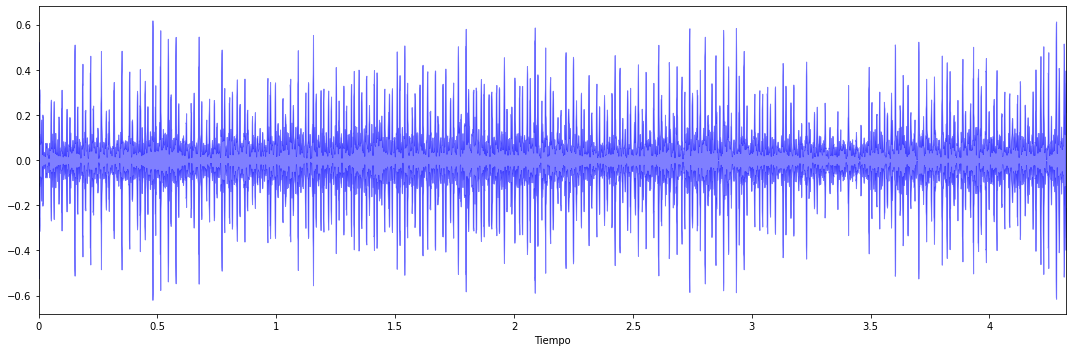

In [2]:
audio = "espectros\\taladro2_aislado.wav"
# audio2 = "espectros\\taladro2.wav"

x, sr = librosa.load(audio)
# x2, sr2 = librosa.load(audio2)

plt.figure(figsize = (15, 5))
librosa.display.waveplot(x, sr, alpha=0.5, color="b")
plt.tight_layout()
plt.xlabel("Tiempo")
plt.show()

Text(0, 0.5, 'Amplitud')

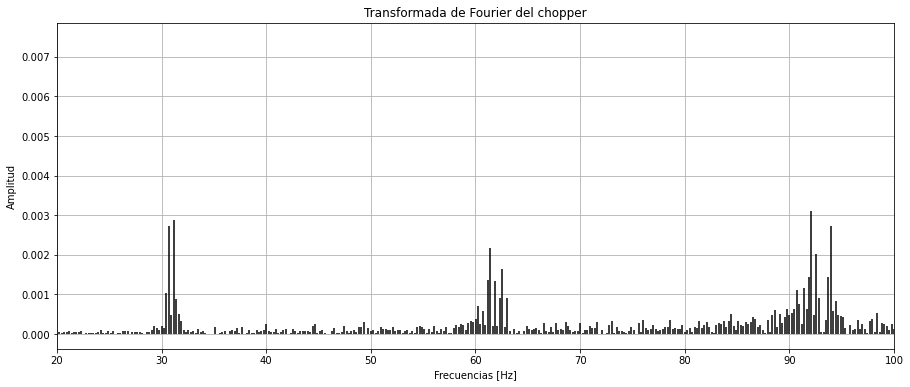

In [108]:
from scipy.fftpack import fft, fftfreq

k= 500

# X = np.abs(x)
X = x
n = len(X[k:])
frq_m = sr
dt = 1/frq_m
tt = dt * n

frq = fftfreq(n, dt)
Y = fft(X) # Normalizada

plt.figure(figsize=(15,6))
plt.vlines(frq, 0, np.abs(Y.imag)/n)
plt.xlim(20, 100); 
plt.grid(); plt.grid(True,'minor',color="#3182bd", alpha=0.2, ls='-', lw=0.2)
plt.title("Transformada de Fourier del chopper"); 
plt.xlabel("Frecuencias [Hz]"); plt.ylabel("Amplitud")
# plt.xscale("log")
# len(X)

In [72]:
frecuencias

array([33.21234428, 33.04586636, 31.63080408, 31.88052095, 30.21574179,
       33.9614949 , 32.29671574, 32.5880521 , 31.71404304, 32.13023783,
       32.79614949, 32.3799547 , 32.33833522, 32.54643262, 33.71177803,
       33.46206116, 33.21234428, 33.83663647, 32.71291053])

In [73]:
maximos = np.unique(np.abs(Y.imag))[-1000:]
s = 0; 
h = len(maximos);
frecuencias=[]

for i in maximos:
    if i> 100: pass
    else:
        if frq[np.where(np.abs(Y.imag) == i)[0][0]]>20 and frq[np.where(np.abs(Y.imag) == i)[0][0]]<50:
            frecuencias.append(frq[np.where(np.abs(Y.imag) == i)[0][0]])
        elif frq[np.where(np.abs(Y.imag) == i)[0][0]]>50 and frq[np.where(np.abs(Y.imag) == i)[0][0]]<75:
            frecuencias.append(frq[np.where(np.abs(Y.imag) == i)[0][0]]/2)
        elif frq[np.where(np.abs(Y.imag) == i)[0][0]]>75 and frq[np.where(np.abs(Y.imag) == i)[0][0]]<100:
            frecuencias.append(frq[np.where(np.abs(Y.imag) == i)[0][0]]/3)

frecuencias = np.array(frecuencias)
ff1 = np.mean(frecuencias); ff2 = np.std(frecuencias)

ff1, ff2

(30.58447209436133, 0.9518265314896482)

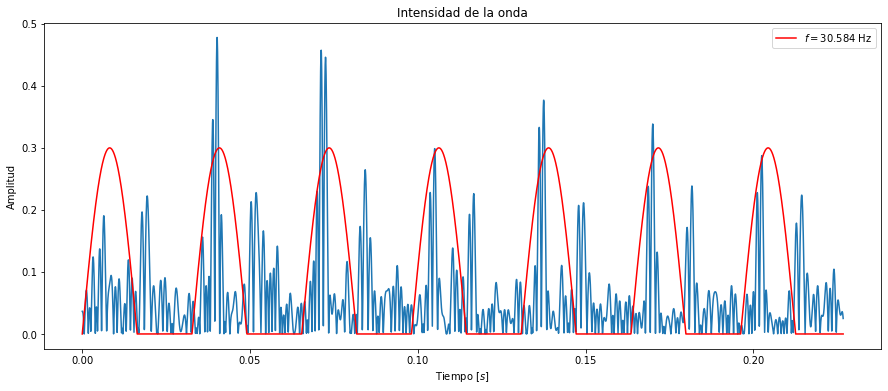

In [112]:
t1 = np.linspace(0, tt, num=n)    
func1 = np.maximum(np.sin(2*np.pi*ff1*t1), t1*0)
# func2 = np.maximum(np.sin(2*np.pi*32*t1+.018), t1*0)

plt.figure(figsize=(15,6))
plt.plot(t1[0:5000], np.abs(X[48000:])[0:5000])
plt.plot(t1[0:5000],  0.3*func1[0:5000], color="r", label= r"$f = 30.584$ Hz")
# plt.plot(t1[0:10000],  0.7*func2[0:10000], color="g", label= r"f = 32")
plt.title("Intensidad de la onda")
plt.xlabel(r"Tiempo [$s$]"); plt.ylabel("Amplitud"); plt.legend()
